# Final Project: UK Solar Electricity Forecasting

This notebook contains the final project for the Time Series course, analyzing and forecasting UK solar electricity generation.

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

In [2]:
# Load the dataset
df = pd.read_csv('../../UK_electricity_solar_2021_2024.csv', parse_dates=['settlement_date'], index_col='settlement_date')
df.head()

,england_wales_demand,item_id,embedded_solar_generation,embedded_solar_capacity,is_holiday
settlement_date,,,,,
2021-01-01 00:00:00,26130.0,UK,0,13080,1
2021-01-01 00:30:00,26281.0,UK,0,13080,1
2021-01-01 01:00:00,25557.0,UK,0,13080,1
2021-01-01 01:30:00,24792.0,UK,0,13080,1
2021-01-01 02:00:00,23933.0,UK,0,13080,1


## 2. Exploratory Data Analysis (EDA)

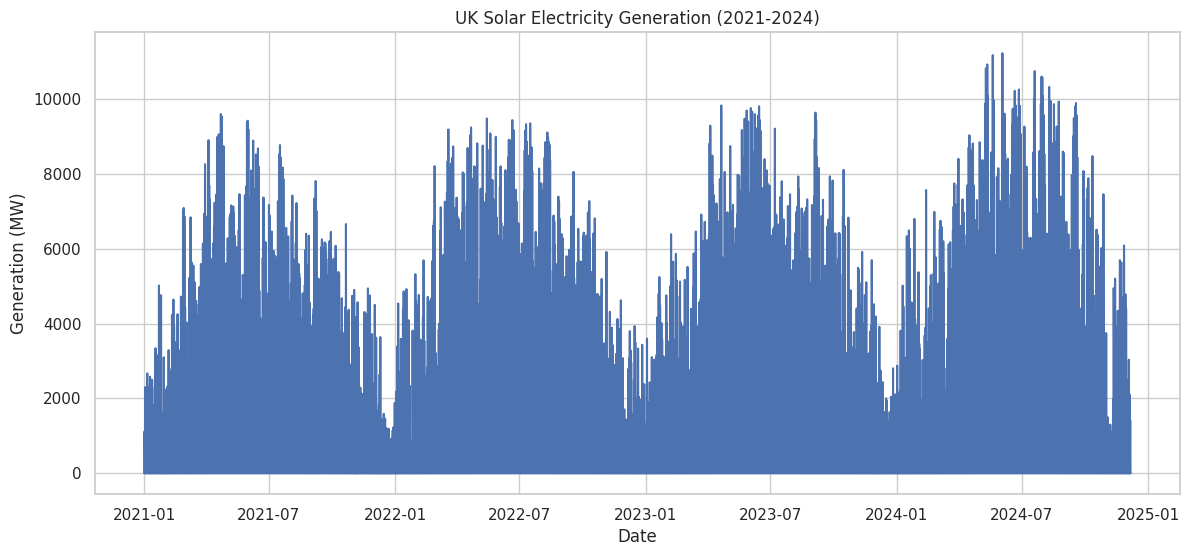

In [3]:
# Quick visualization
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['embedded_solar_generation'])
plt.title('UK Solar Electricity Generation (2021-2024)')
plt.xlabel('Date')
plt.ylabel('Generation (MW)')
plt.show()

In [5]:
# Generate a profiling report (can take a minute on large datasets)
profile = ProfileReport(df, title='Solar Profiling Report', minimal=True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 156.53it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## 3. Time Series Analysis
Check for stationarity and decompose the series.

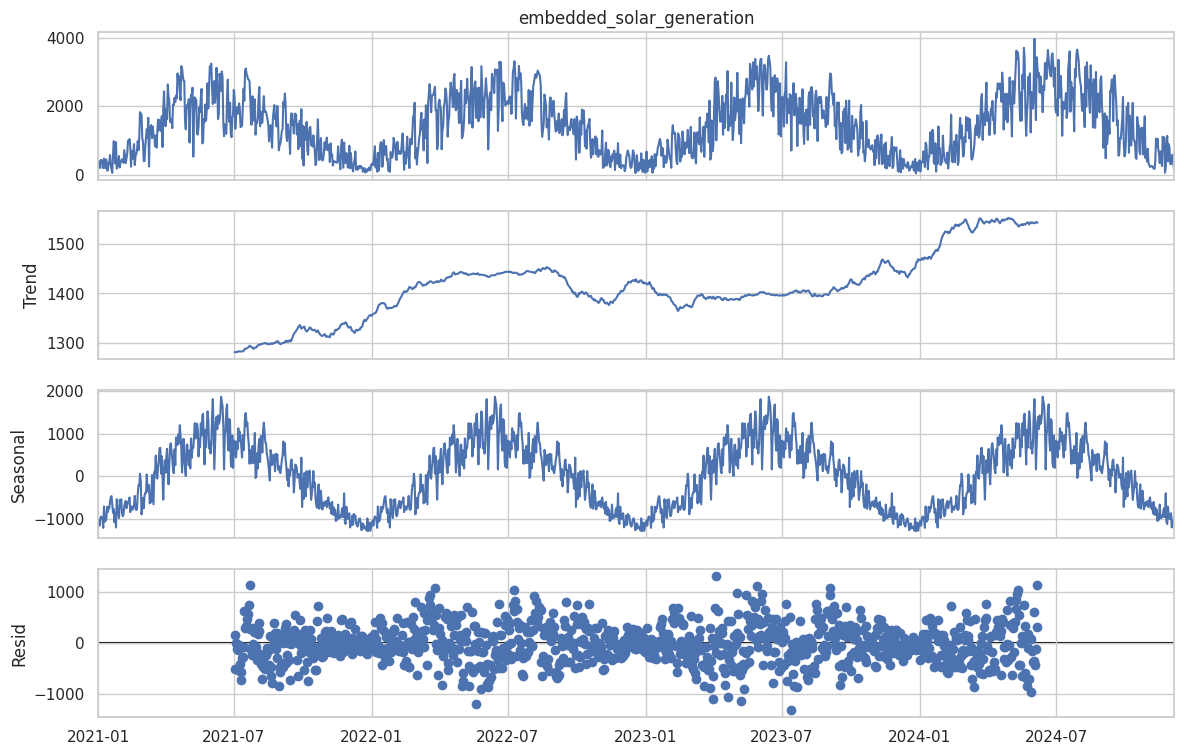

In [7]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Resample to daily frequency to smooth the half-hourly data and speed up modeling
df_daily = df.resample('D').mean(numeric_only=True)
df_daily.dropna(inplace=True)

# Seasonal Decomposition
result = seasonal_decompose(df_daily['embedded_solar_generation'], model='additive', period=365)
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

In [8]:
def adf_test(series):
    print('Augmented Dickey-Fuller Test:')
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print('Reject the null hypothesis (H0), the data is stationary.')
    else:
        print('Fail to reject the null hypothesis (H0), the data is non-stationary.')

adf_test(df_daily['embedded_solar_generation'])

Augmented Dickey-Fuller Test:
ADF Statistic: -2.6669
p-value: 0.0799
Fail to reject the null hypothesis (H0), the data is non-stationary.


### Autocorrelation (ACF & PACF)

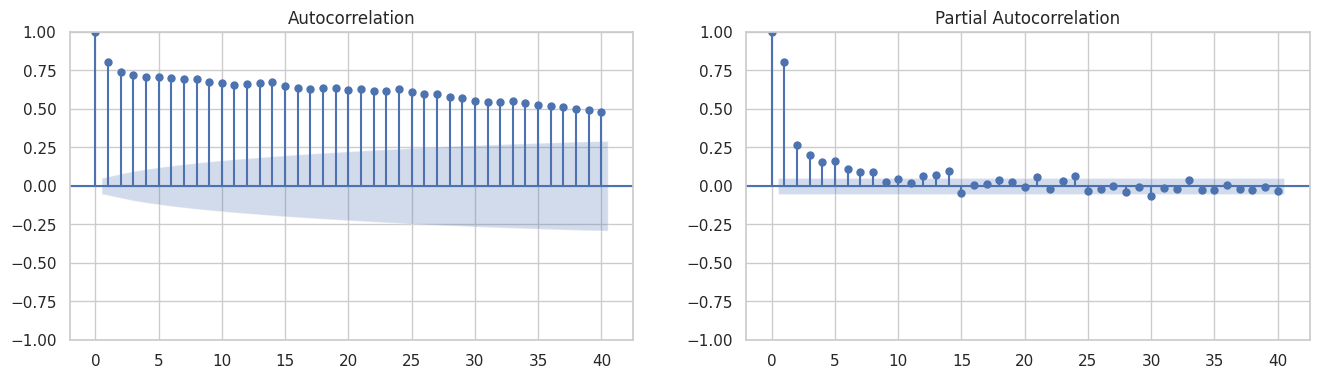

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df_daily['embedded_solar_generation'].dropna(), ax=axes[0], lags=40)
plot_pacf(df_daily['embedded_solar_generation'].dropna(), ax=axes[1], lags=40)
plt.show()

## 4. Feature Engineering
Create basic time-based features.

In [10]:
df_daily['month'] = df_daily.index.month
df_daily['day_of_week'] = df_daily.index.dayofweek
# Add lag variable based on ACF
df_daily['lag_1'] = df_daily['embedded_solar_generation'].shift(1)
df_daily.dropna(inplace=True)
df_daily.head()

,england_wales_demand,embedded_solar_generation,embedded_solar_capacity,is_holiday,month,day_of_week,lag_1
settlement_date,,,,,,,
2021-01-02,28615.479167,398.625000,13080.0,0.0,1,5,197.812500
2021-01-03,28565.645833,361.687500,13080.0,0.0,1,6,398.625000
2021-01-04,32084.229167,193.541667,13080.0,0.0,1,0,361.687500
2021-01-05,32712.729167,431.166667,13080.0,0.0,1,1,193.541667
2021-01-06,33762.604167,378.041667,13080.0,0.0,1,2,431.166667


## 5. Modeling (ARIMA)
Split into train and test sets chronologically.

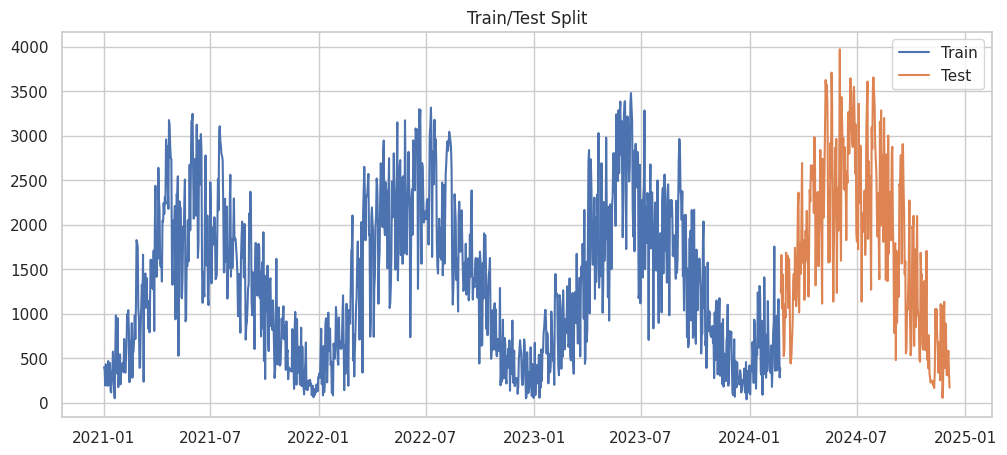

In [11]:
train_size = int(len(df_daily) * 0.8)
train, test = df_daily.iloc[:train_size], df_daily.iloc[train_size:]

plt.figure(figsize=(12, 5))
plt.plot(train.index, train['embedded_solar_generation'], label='Train')
plt.plot(test.index, test['embedded_solar_generation'], label='Test')
plt.legend()
plt.title('Train/Test Split')
plt.show()

In [12]:
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm

# Note: Pass the original (non-differenced) data. The model handles differencing internally via `d`.
model = ARIMA(train['embedded_solar_generation'], order=(7, 1, 1))
results = model.fit()
print(results.summary())

                                   SARIMAX Results                                   
Dep. Variable:     embedded_solar_generation   No. Observations:                 1147
Model:                        ARIMA(7, 1, 1)   Log Likelihood               -8629.518
Date:                       Wed, 01 Apr 2026   AIC                          17277.035
Time:                               23:09:14   BIC                          17322.432
Sample:                           01-02-2021   HQIC                         17294.174
                                - 02-22-2024                                         
Covariance Type:                         opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2733      0.053      5.126      0.000       0.169       0.378
ar.L2         -0.0476      0.039     -1.227      0.220      -0.124       0.

## 6. Evaluation & Forecasting

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# Forecast on the test set length
forecast_obj = results.get_forecast(steps=len(test))
forecast_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int()

# Metrics
mae = mean_absolute_error(test['embedded_solar_generation'], forecast_mean)
rmse = np.sqrt(mean_squared_error(test['embedded_solar_generation'], forecast_mean))
mape = mean_absolute_percentage_error(test['embedded_solar_generation'], forecast_mean)

print(f'MAE:  {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAPE: {mape:.2%}')

MAE:  1245.48
RMSE: 1498.48
MAPE: 69.50%


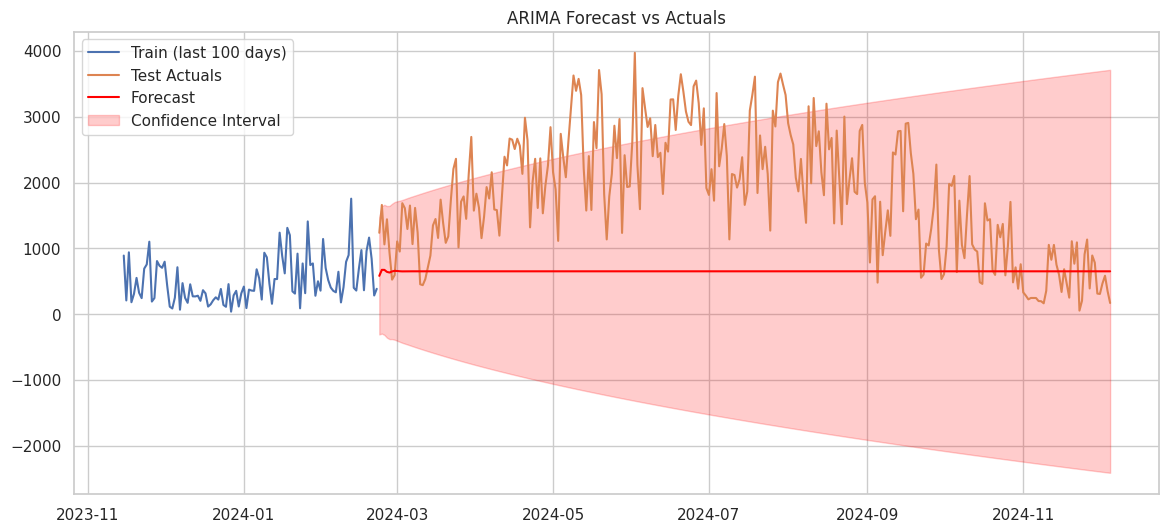

In [14]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train['embedded_solar_generation'][-100:], label='Train (last 100 days)')
plt.plot(test.index, test['embedded_solar_generation'], label='Test Actuals')
plt.plot(test.index, forecast_mean, label='Forecast', color='red')
plt.fill_between(test.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='red', alpha=0.2, label='Confidence Interval')
plt.title('ARIMA Forecast vs Actuals')
plt.legend()
plt.show()